# $\beta$-VAE trained on the Fashion-MNIST dataset

Notebook containing the training and results for the fully connected VAE.

### Loading the data

In [15]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy
import os
plt.style.use('ggplot')
import importlib
# Pytorch
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# Project specifik modules
data=[]
pos_limits = [-10, 10]
vel_limits = [-10, 10]

from utils import load_dataset, load_small_dataset, result_grid
from models import fcVAE, MinMaxCenterScaler
from solver import Solver
folder = "/home/kartik/mpot/data/"
filename = ["occupancy_data.pt"]
for file in filename:
    d = torch.load(os.path.join(folder,file))
    traj = d['state trajectory']
    # traj_data = traj.view(-1,4).cpu()
    data.append(traj)
data = torch.cat(data,dim=0)
num_goals =3
num_points = 33
traj_len = 64
dim=2
state_dim=4


In [6]:
if isinstance(pos_limits, torch.Tensor):
    pos_limits = pos_limits.clone().to("cuda")
else:
    pos_limits = torch.tensor(pos_limits)
if pos_limits.ndim == 1:
    pos_limits = pos_limits.unsqueeze(0).repeat(dim, 1)
pos_scaler = MinMaxCenterScaler(dim_range=[0, dim], min=pos_limits[:, 0], max=pos_limits[:, 1])
if isinstance(vel_limits, torch.Tensor):
    vel_limits = vel_limits.clone().to("cuda")
else:
    vel_limits = torch.tensor(vel_limits)
if vel_limits.ndim == 1:
    vel_limits = vel_limits.unsqueeze(0).repeat(dim, 1)
vel_scaler = MinMaxCenterScaler(dim_range=[dim, state_dim], min=vel_limits[:, 0], max=vel_limits[:, 1])
scaler = [pos_scaler, vel_scaler]
print(data.device)
for scale in scaler:
    scale(data)


cuda:0


In [13]:
data

tensor([[[-8.9935e-01, -9.0069e-01,  1.4288e-01,  2.8561e-01],
         [-8.7968e-01, -8.7201e-01,  2.6883e-01,  2.6181e-01],
         [-8.5192e-01, -8.4711e-01,  2.9458e-01,  2.3148e-01],
         ...,
         [ 8.5082e-01, -4.5081e-02,  2.3463e-01,  2.3514e-01],
         [ 8.7341e-01, -2.0861e-02,  2.4828e-01,  2.5364e-01],
         [ 9.0044e-01, -1.5459e-03,  2.8577e-01,  1.4299e-01]],

        [[-8.9678e-01, -8.9317e-01,  2.2757e-04,  3.8612e-04],
         [-8.8287e-01, -8.7839e-01,  2.6888e-01,  2.6203e-01],
         [-8.5259e-01, -8.4666e-01,  2.9454e-01,  2.3154e-01],
         ...,
         [ 8.4931e-01, -4.5863e-02,  2.3463e-01,  2.3518e-01],
         [ 8.8012e-01, -1.7281e-02,  2.4846e-01,  2.5372e-01],
         [ 8.9339e-01, -3.8401e-03,  3.6693e-04,  2.4760e-04]],

        [[-8.9831e-01, -8.9620e-01,  1.6022e-04,  2.5403e-04],
         [-8.8360e-01, -8.7902e-01,  2.6892e-01,  2.6225e-01],
         [-8.5400e-01, -8.4946e-01,  2.9456e-01,  2.3172e-01],
         ...,
         

In [16]:
traj = data
traj_shape = traj.shape
# traj.view(traj_shape[0], -1, traj_len, 4)
traj_data = traj.view(-1,4).cpu()
traj_data.shape

torch.Size([487872, 4])

In [17]:
total_size = len(traj_data)
train_size = int(0.40*total_size)
# test_size = int(0.15*total_size)
val_size = int(0.10*total_size)
test_size = total_size - train_size - val_size 
train_set, val_set, test_set = random_split(traj_data, [train_size, val_size, test_size])
print("total size: ", total_size)
print("train size: ", train_size)
print("test size: ", test_size)
print("val size: ", val_size)

traj_data

total size:  487872
train size:  195148
test size:  243937
val size:  48787


tensor([[-8.9935e+00, -9.0069e+00,  1.4288e+00,  2.8561e+00],
        [-8.7968e+00, -8.7201e+00,  2.6883e+00,  2.6181e+00],
        [-8.5192e+00, -8.4711e+00,  2.9458e+00,  2.3148e+00],
        ...,
        [ 8.4983e+00, -1.5647e-01,  2.4211e+00,  2.2343e+00],
        [ 8.8105e+00, -2.2579e-02,  2.5242e+00,  2.4011e+00],
        [ 8.9938e+00,  9.5130e-03,  4.8330e-04, -2.6220e-04]])

### Specifing parameters for model and training

In [6]:
kwargs = {'learning_rate':5e-4,
          'batch_size' :   2048,
          'lr_rate_decay': .5,
          'decay_every_': 2, 
          'weight_decay': 1e-4}

kl_weight = kwargs['batch_size']/len(train_set)
# importlib.reload(fcVAE)
model = fcVAE(input_size=4,in_channels=1, latent_dim=4, beta= 0.5, kl_weight=kl_weight)
print(model)
solver = Solver(model, train_set, val_set, test_set, **kwargs)
#small_solver = Solver(model, small_train, val_set, test_set, **kwargs)

fcVAE(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
  )
  (linear_mu): Linear(in_features=256, out_features=4, bias=True)
  (linear_logsigma): Linear(in_features=256, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=4, bias=True)
  )
)


### Training

In [7]:
solver.train(30)

Validation: 100%|██████████| 24/24 [00:00<00:00, 52.64it/s, Epoch=30/30, KL_loss=2.93, Loss=0.0262, MSE_loss=0.0108]


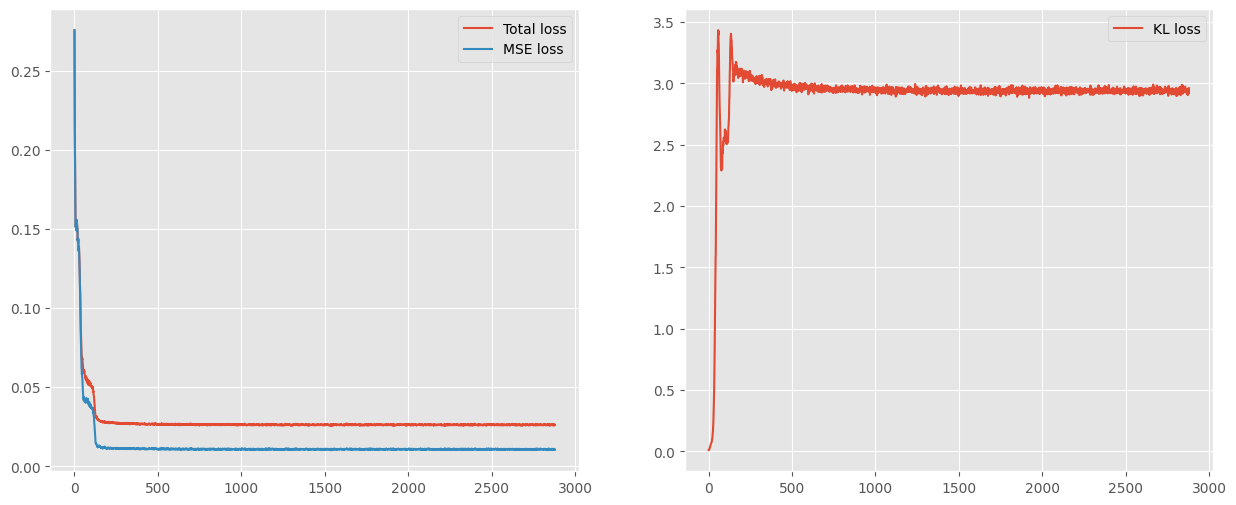

In [9]:
solver.plot_training_loss()

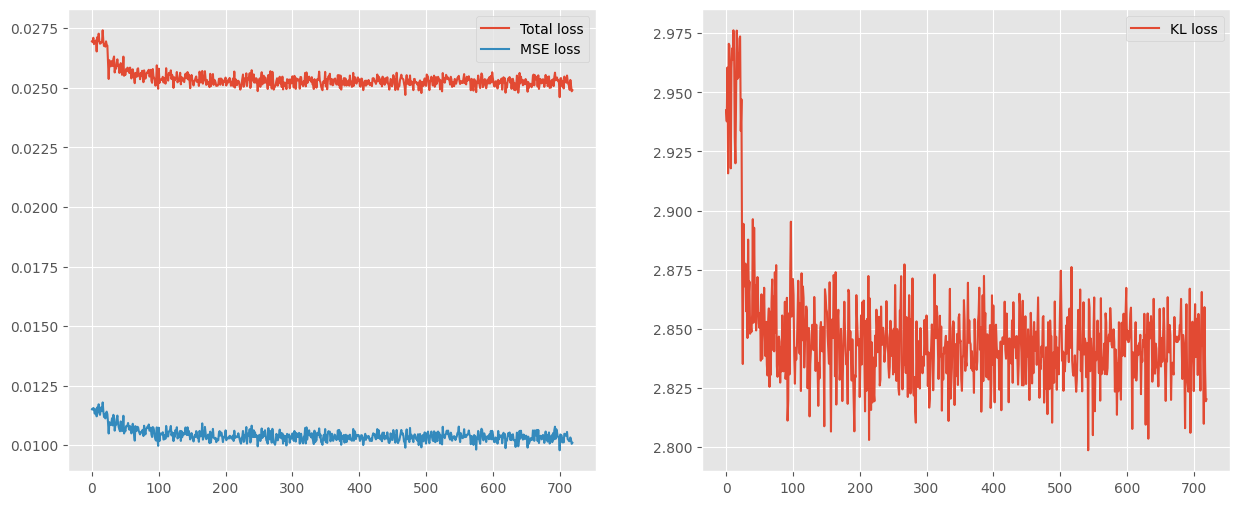

In [64]:
solver.plot_val_loss()

### Showing examples of reconstruction

In [20]:
test_x = next(enumerate(torch.utils.data.DataLoader(test_set, batch_size=100)))
output, (_, _) = model.forward(test_x[1])
output[0],test_x[1][0]

(tensor([0.4228, 0.4666, 0.3312, 0.3096], grad_fn=<SelectBackward0>),
 tensor([0.4007, 0.4575, 0.3595, 0.2196]))

## Analysis

In [10]:
model.sample(20)

tensor([[-2.2415,  1.1983, -0.3910, -0.2663],
        [-0.2284, -2.9323,  0.3217, -0.0580],
        [-0.8728, -1.0773, -0.7472,  0.2246],
        [ 0.0168,  1.8576,  0.0885,  0.1165],
        [-0.1907,  1.8030,  1.7692, -0.2718],
        [ 0.8777,  1.9470,  1.0251,  0.4153],
        [-1.3993, -2.5979,  0.0287,  0.7244],
        [-1.1257, -0.4176,  0.7536,  0.4030],
        [-0.1969, -0.4235,  0.8842,  0.6155],
        [-0.9200, -1.6586,  0.2077, -0.3775],
        [ 0.5151, -1.6593,  1.4612,  0.6831],
        [ 1.1465,  0.2682,  0.7260,  0.7305],
        [ 0.0491, -0.2287,  1.1573,  1.3934],
        [-0.8790, -0.0358, -0.6437,  0.3052],
        [-0.0984, -0.6847,  0.9106,  0.4424],
        [ 2.4701,  1.3191, -0.5068, -0.3368],
        [-1.3537,  0.2306,  1.2856, -0.2747],
        [ 0.4630, -0.1850,  0.4058,  0.5666],
        [ 0.1438, -0.5572,  0.8759,  1.0416],
        [-1.0244, -1.5108,  0.7534, -0.6128]], grad_fn=<AddmmBackward0>)

In [11]:
# torch.save(model, "mpot_occupancy1_mse_scaled_beta_0.5_l4.pt")

In [66]:
_,test_x = next(enumerate(torch.utils.data.DataLoader(test_set, batch_size=1)))
test_x

tensor([[0.4007, 0.4575, 0.3595, 0.2196]])

In [67]:
test_x_scale = test_x.clone().to('cuda')
for scale in scaler:
    scale.inverse(test_x_scale)
test_x_scale

tensor([[4.0070, 4.5751, 3.5951, 2.1958]], device='cuda:0')

In [69]:
mu, sigma = model.encode(test_x)
mu, sigma

(tensor([[-0.0058,  1.1409,  0.0016, -0.0084]], grad_fn=<AddmmBackward0>),
 tensor([[-0.0245, -3.7119, -0.0169, -2.5662]], grad_fn=<AddmmBackward0>))

In [70]:
z = model.reparameterization(mu, sigma)
z

tensor([[0.6931, 0.9996, 0.6905, 0.0373]], grad_fn=<AddBackward0>)

In [71]:
z_prime = z.clone()
z_prime [0]+=0.1
z_prime

tensor([[0.7931, 1.0996, 0.7905, 0.1373]], grad_fn=<CopySlices>)

In [72]:
output_prime = model.decode(z_prime)
output = model.decode(z)

output, output_prime

(tensor([[0.3422, 0.3857, 0.3063, 0.3143]], grad_fn=<AddmmBackward0>),
 tensor([[0.3655, 0.4568, 0.3059, 0.3146]], grad_fn=<AddmmBackward0>))

In [73]:
output_prime_scale = output_prime.clone().to('cuda')
for scale in scaler:
    scale.inverse(output_prime_scale)
output_scale = output.clone().to('cuda')
for scale in scaler:
    scale.inverse(output_scale)
output_scale,output_prime_scale

(tensor([[3.4221, 3.8568, 3.0626, 3.1430]], device='cuda:0',
        grad_fn=<CopySlices>),
 tensor([[3.6551, 4.5676, 3.0594, 3.1463]], device='cuda:0',
        grad_fn=<CopySlices>))

In [74]:
mu_prime, sigma_prime = model.encode(output_prime)


In [75]:
z_prime_prime = model.reparameterization(mu_prime, sigma_prime)
z_prime_prime

tensor([[1.7848, 0.9219, 0.3066, 0.4830]], grad_fn=<AddBackward0>)

tensor([4.4230, 8.2524, 9.5034, 4.7898], grad_fn=<MeanBackward1>)


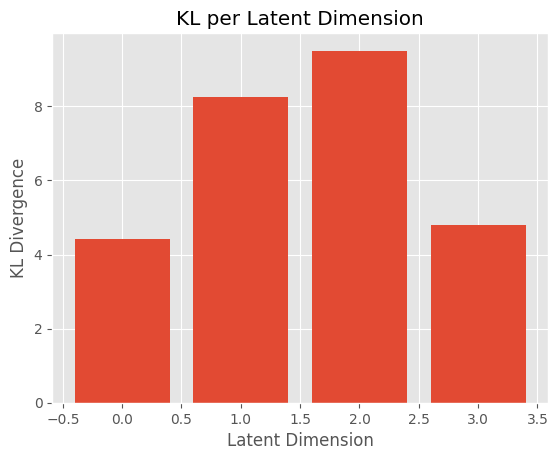

In [22]:

def compute_kl_divergence_per_dim(mu, logvar):
    # mu, logvar: (batch_size, latent_dim)
    kl_per_dim = 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1)
    # Mean across batch to get average KL per dimension
    kl_mean = kl_per_dim.mean(dim=0)  # shape: (latent_dim,)
    return kl_mean

# Example: Suppose your encoder returns:
# mu, logvar = encoder(x)
# And your latent dimension is 4
_,test_x = next(enumerate(torch.utils.data.DataLoader(test_set, batch_size=1)))
model = fcVAE(input_size=4,in_channels=1, latent_dim=4, beta= 0.5, kl_weight=1)
model_name = "/home/kartik/mpot/pytorch-Variational-Autoencoder/mpot_occupancy_mse_beta_0-05_l4.pt"
model = torch.load(model_name,weights_only=False)
# mu = torch.randn(128, 4)         # Example output
# logvar = torch.randn(128, 4)     # Example output
mu, logvar = model.encode(test_x)

kl_dimwise = compute_kl_divergence_per_dim(mu, logvar)
print(kl_dimwise)
# Plotting
plt.bar(range(len(kl_dimwise)), kl_dimwise.detach().numpy())
plt.xlabel('Latent Dimension')
plt.ylabel('KL Divergence')
plt.title('KL per Latent Dimension')
plt.grid(True)
plt.show()